In [7]:
from strategies.run_daily import get_daily_result, get_daily_signals
from strategies.run_allen import get_allen_result
from strategies.run_gino import get_gino_result

from evaluation.stats import sharpe_0050, sharpe
from datetime import datetime
import pandas as pd
import yaml
import finlab
from finlab import data

finlab.login("ntSS3778pZi2FfkeYxXP0p+S0iI4AggkcphAUxh/lTVrWqT2FreKQsDkTA92CM7d#vip_m")
f = open("config/backtest.yaml")
cfg = yaml.safe_load(f)
result_dir = "results/Example_Result"

start_date = datetime.strptime("2021-01-01", "%Y-%m-%d")
end_date = datetime.strptime("2025-11-01", "%Y-%m-%d")

# buy_signals = get_daily_signals(cfg, result_dir, k=30, cash_quantile=0.5, start_date=start_date, end_date=end_date)

result = get_allen_result(
    cfg,
    result_dir,
    start_date=start_date,
    end_date=end_date,
)
# print(result)

# breakpoint()
roi = result["model"].returns.iloc[-1] / result["model"].returns.iloc[0] - 1
print("ROI:", roi)
sharpe_ratio = sharpe(result["model"].returns)
print("Sharpe Ratio:", sharpe_ratio)

with data.universe("ETF"):
    close_df = data.get("etl:adj_close")
    close_df = close_df["0050"]
close_df = close_df[
    (close_df.index >= result["model"].returns.index[0])
    & (close_df.index <= result["model"].returns.index[-1])
]
etf_roi = close_df.iloc[-1] / close_df.iloc[0] - 1
print("0050 ROI:", etf_roi)
etf_sharpe = sharpe_0050(result["model"].returns, close_df)

輸入成功!
ROI: 3.4435045424590145
Sharpe Ratio: 1.2471294142965947
0050 ROI: 1.412600176134291


Sharpe(0050) Ratio: 0.6419831620439332


<Axes: title={'center': 'Backtest Strategy Returns'}>

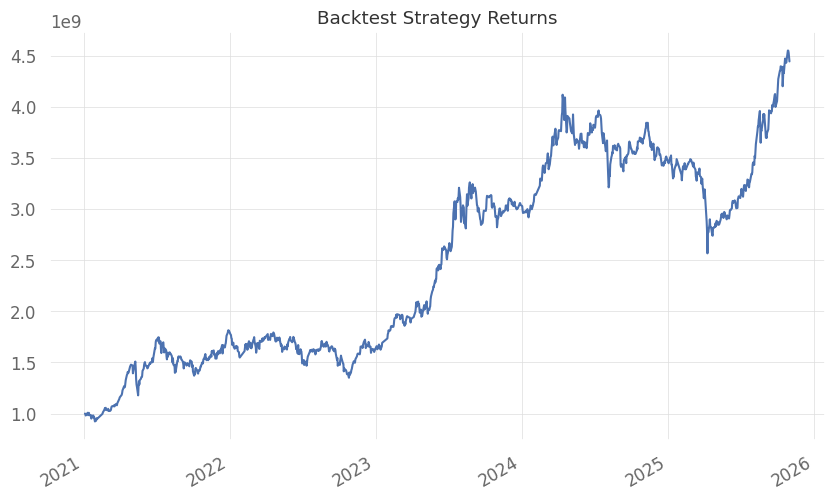

In [8]:
print("Sharpe(0050) Ratio:", etf_sharpe)
result["model"].returns.plot(title="Backtest Strategy Returns")

Mean Invest Ratio: 0.99112778463818


<Axes: title={'center': 'Backtest Strategy Invest Ratio'}>

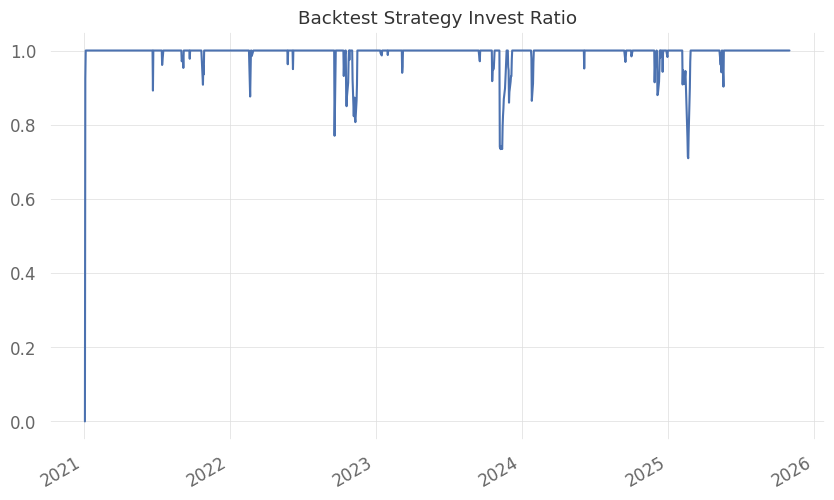

In [9]:
print("Mean Invest Ratio:", result["model"].invest_ratio.mean())
result["model"].invest_ratio.plot(title="Backtest Strategy Invest Ratio")